# Big Data & AI Lab 1: Time series anomaly detection

- Warm up
- Detecting anomalies
- Bonus: Analyse datasets

## Warm up session
0. Setup the environment
1. Load the time series 'kdd_tsad_135' from the aeon library
2. Plot the time series
3. Highlight the anomalies in red
4. Calculate and display the average number of anomalies.

### Setup the environment

In [1]:
!pip install aeon
!pip install pyod


Installing packages through the IPython console doesn't work reliably in Spyder. Please use a system terminal to do that, i.e. cmd.exe on Windows, Terminal on macOS or xterm on Linux.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time

### Load the data

In [3]:
from aeon.datasets import load_kdd_tsad_135
from aeon.datasets import load_anomaly_detection

In [4]:
data, label = load_kdd_tsad_135()
#data, label = load_anomaly_detection(
#     name=("KDD-TSAD", "002_UCR_Anomaly_DISTORTED2sddb40")
# )

### Plot the data

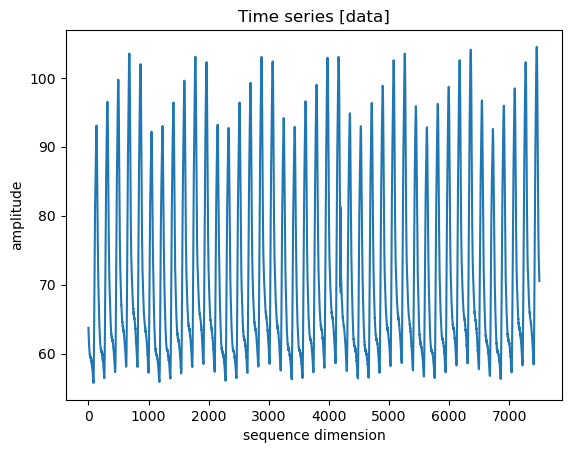

In [5]:
# TODO: Plot the time series
plt.plot(data)
plt.title("Time series [data]")
plt.xlabel("sequence dimension")
plt.ylabel("amplitude")
plt.show()

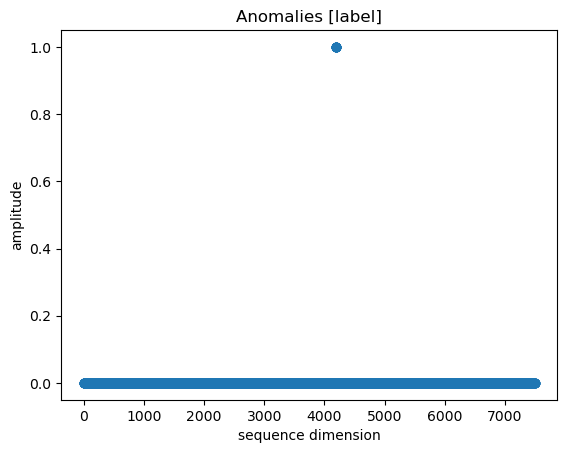

In [6]:
# TODO: Plot the label
plt.scatter([i for i in range(len(label))],label)
plt.title("Anomalies [label]")
plt.xlabel("sequence dimension")
plt.ylabel("amplitude")
plt.show()

### Highlight the anomalies in red

In [7]:
# TODO: Implement the following function
def plot_signal_with_anomalies(data,label, title=None):
    x=[]
    y=[]
    for i in range(len(data)) :
        if(label[i]>=0.1) :
            y.append(data[i])
            x.append(i)
    plt.plot(data)
    plt.plot(x,y)
    plt.show()
    pass

[63.73215 63.35068 63.02261 ... 71.2738  70.81222 70.52612]


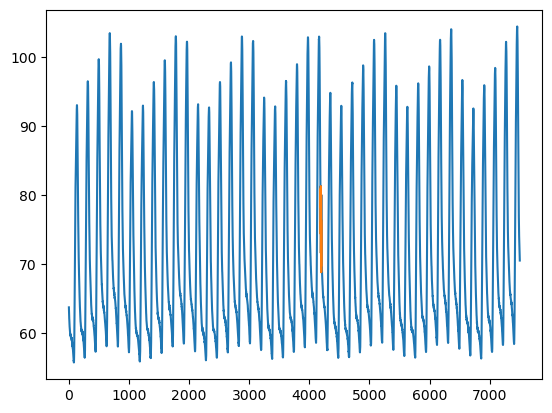

In [8]:
# TODO: Use the function you implemented to visualize the time series with the anomalies
print(data)
plot_signal_with_anomalies(data,label)

### Compute the number of anomalies

In [9]:
# TODO: Implement the following function
def compute_number_of_anomalies(y):
    s=0
    for i in range(len(y)):
        if(label[i]>=0.1) :
            s=s+1
    return s
    pass
compute_number_of_anomalies(label)

12

## Detecting anomalies

### Setup

In [10]:
from aeon.utils.discovery import all_estimators
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

# detectors = all_estimators("anomaly-detector")
# detectors

In [11]:
from aeon.anomaly_detection.series.distance_based import STOMP # YES
from aeon.anomaly_detection.series.outlier_detection._iforest import IsolationForest # YES
from aeon.anomaly_detection.series.distance_based._kmeans import KMeansAD # YES
from aeon.anomaly_detection.series.distance_based._lof import LOF # YES
from aeon.anomaly_detection.series.outlier_detection._one_class_svm import OneClassSVM # YES but bad

from aeon.anomaly_detection.series._pyodadapter import PyODAdapter # These two work together
from pyod.models.cblof import CBLOF # These two work together

### Compute anomaly scores

**About windowing**

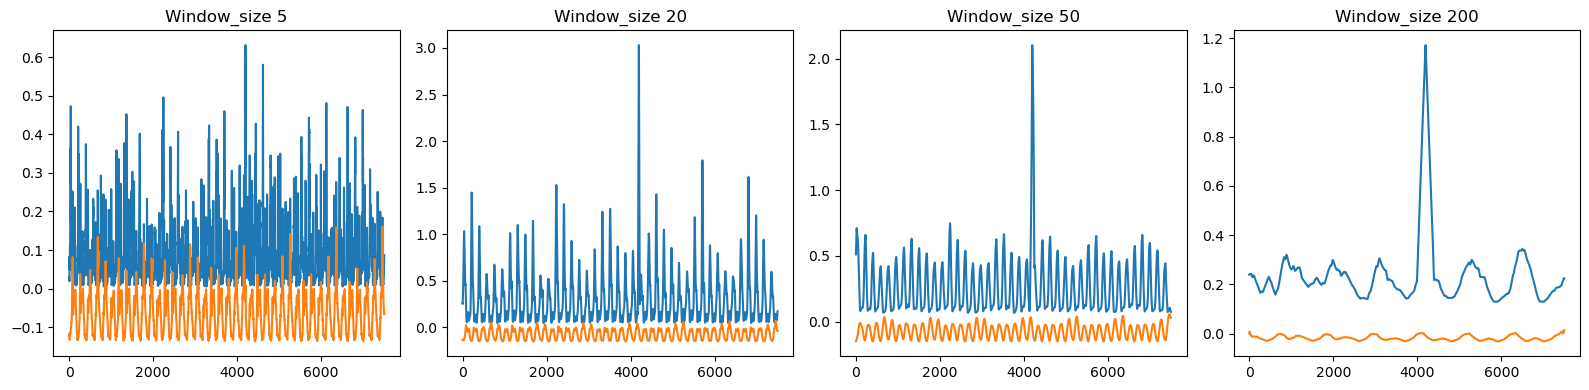

In [12]:
#Remark
#The function data cannot toke a python list
x = np.array(data, dtype=float).reshape(-1, 1) #reshape needed for MinMax
x=MinMaxScaler().fit_transform(x)
# STOMP want 1D
x = x.ravel() # transforms (n,1) en (n,)
#STOMP get in argument the sub-sequence 
measures = [5,20,50,200]
detector_STOMP = [STOMP(window_size=el) for el in measures]
detector_IsolationForest = [IsolationForest(window_size=el) for el in measures]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    axes[i].plot(detector_STOMP[i].fit_predict(x))
    axes[i].plot(detector_IsolationForest[i].fit_predict(x))
    axes[i].set_title(f"Window_size {measures[i]}")

plt.tight_layout()
plt.show()

>> The window parameters allows in the others case to smoothen the data entry. Modifying windows size is only pertinent with the STOMP (his method is to check the patterns by chunk not smoothen).
>> We consider no argument => op

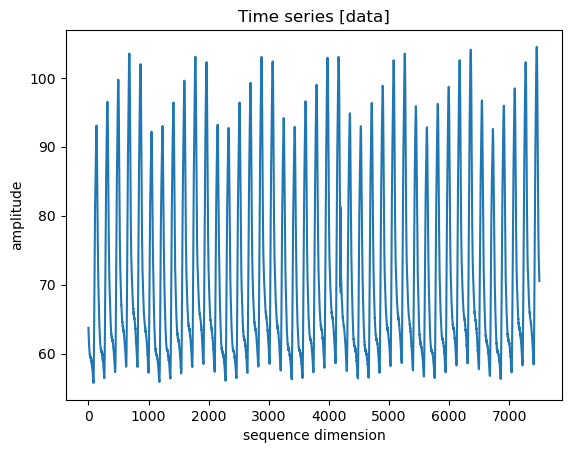

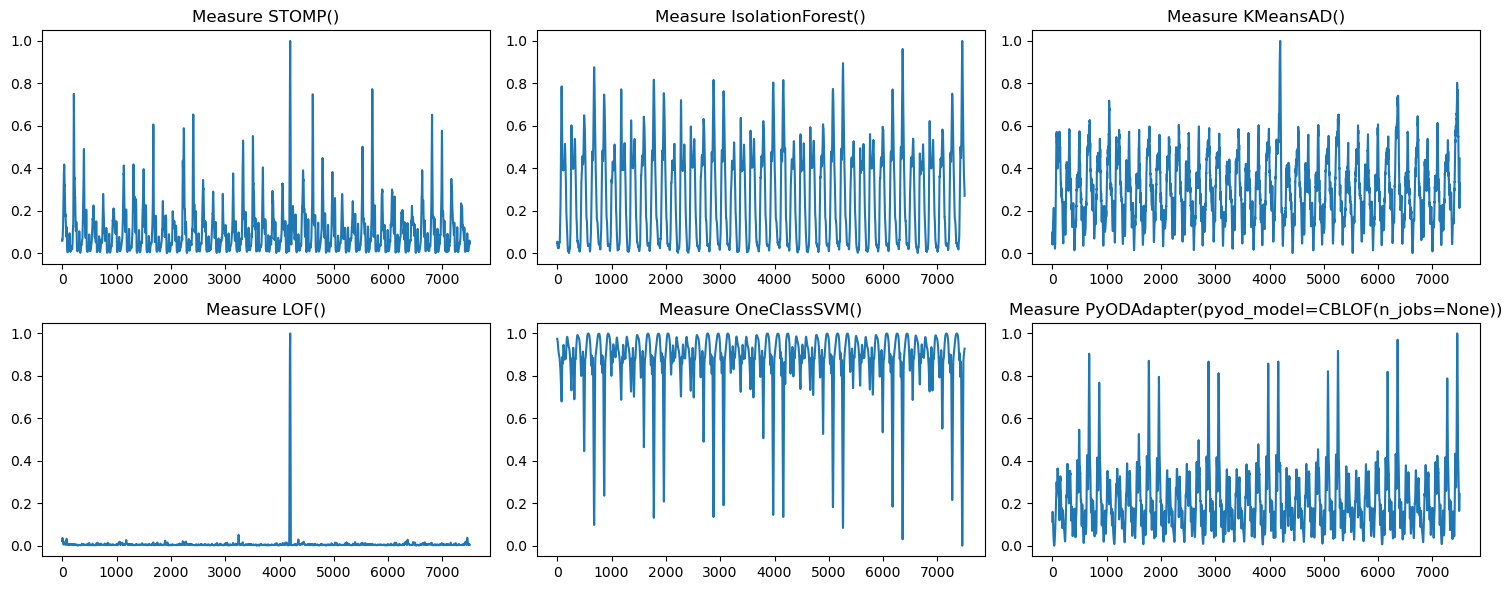

In [13]:
results = {"method": [], "score": [], "runtime" :[]} # Save your results here, use it as a list of dictionaries with keys {method, score, runtime}
detectors = [STOMP(), IsolationForest(), KMeansAD(), LOF(), OneClassSVM(), PyODAdapter(CBLOF())]

# TODO: Compute the anomaly scores from all detectors and measure run time
# TODO: Plot the original time series and the computed scores in subplots, use matplotlib
plt.plot(data)
plt.title("Time series [data]")
plt.xlabel("sequence dimension")
plt.ylabel("amplitude")
plt.show()

import time
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()  # to acess to the axes like lists


for i in range(6):
    time_meas=time.time()
    x=detectors[i].fit_predict(data)
    time_meas=time.time()-time_meas
    results["method"].append(detectors[i])
    results["score"].append(MinMaxScaler().fit_transform(np.array(x).reshape(-1,1)).ravel()) #to normalize the data
    results["runtime"].append(time_meas)
    axes[i].plot(MinMaxScaler().fit_transform(np.array(x).reshape(-1,1)).ravel())
    axes[i].set_title(f"Measure {detectors[i]}")

plt.tight_layout()
plt.show()


>> For OneClassSVM the way we will score is problematic, to detect anomalies we should start from below. That's why the next bit of code will reverse the OneClassSVM

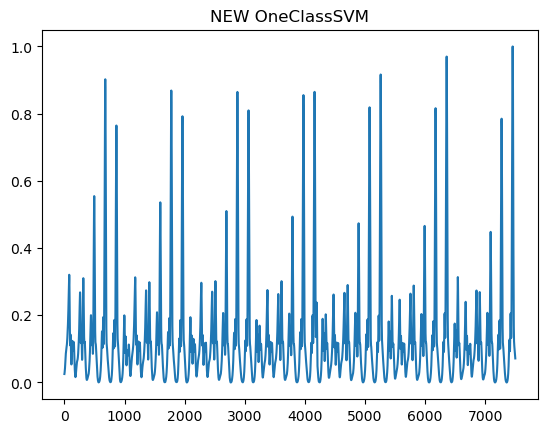

In [14]:
#reverse OneClassSVM
results["score"][4] = [abs(1-results["score"][4][i]) for i in range(len(results["score"][4]))]
plt.plot(results["score"][4])
plt.title("NEW OneClassSVM")
plt.show()

### Compute threshold-based metrics

In [15]:
from sklearn.metrics import f1_score, precision_recall_curve, auc

>> We know that each points are statistically-safe if they are from 3std from the mean.

In [16]:
# TODO: Compute the statistically-safe threshold for all scores
# calculate mean and variance
def calc_threshold(sample):
    mean=0
    variance=0
    for i in range(len(sample)) :
        mean=mean+sample[i]
        variance=variance+sample[i]**2
    mean=mean/len(sample)
    variance= variance/len(sample) - mean**2 #Koenig-Huygens
    return [-3* np.sqrt(variance) + mean,3* np.sqrt(variance) + mean]
    
results["threshold"]=[] 
for elem in results["score"] :
    results["threshold"].append(calc_threshold(elem))

for i in range(len(results["threshold"])):
    print(results["threshold"][i])
"""
for i in range(len(esults["score"])):
    for elem in results["score"][i]:
        if (abs(elem) >= threshold):
            elem['threshold'] = 
"""

[np.float64(-0.24400766016676062), np.float64(0.4429767234898003)]
[np.float64(-0.3862608090616145), np.float64(0.9276337419356013)]
[np.float64(-0.17462851562637555), np.float64(0.7604837498573409)]
[np.float64(-0.11886903007626792), np.float64(0.13419591630070365)]
[np.float64(-0.3276860907735238), np.float64(0.5818086752326912)]
[np.float64(-0.2425577167399349), np.float64(0.6689186388977257)]


'\nfor i in range(len(esults["score"])):\n    for elem in results["score"][i]:\n        if (abs(elem) >= threshold):\n            elem[\'threshold\'] = \n'

In [17]:
# TODO: Use the anomaly threshold you found to compute the F1-score
TP=[0 for i in range(len(detectors))]
FP=[0 for i in range(len(detectors))]
FN=[0 for i in range(len(detectors))]
TN=[0 for i in range(len(detectors))] #useless
for i in range(len(detectors)) : #each i represents a diff detector
    for j in range(len(label)) :
        if((results["score"][i][j] <= results["threshold"][i][0]) or (results["score"][i][j] >= results["threshold"][i][1])):
            if(label[j] >= 0.1):
                TP[i]=TP[i]+1
            else :
                FP[i]=FP[i]+1
        else :
            if(label[j] >= 0.1):
                FN[i]=FN[i]+1
            else :
                TN[i]=TN[i]+1

#Yes I do calculate result for the second question after because it's convenient
precision=[-1 for i in range(len(detectors))] #0 means error
recall=[-1 for i in range(len(detectors))]
F1_score=[-1 for i in range(len(detectors))]
for k in range(len(detectors)):
    if(TP[k]+FP[k] != 0):
        precision[k]=TP[k]/(TP[k]+FP[k])
    if(TP[k]+FN[k] != 0):    
        recall[k]=TP[k]/(TP[k]+FN[k])
    if(precision[k] not in (0,-1) and recall[k] not in (0,-1)):
        F1_score[k] = 2*precision[k]*recall[k]/(precision[k]+recall[k])
print(F1_score)
# for i, elem in enumerate(results):
    # elem['predicted_labels'] = ?
    # elem['f1_score'] = ?

[0.14285714285714288, -1, 0.5581395348837209, 0.6486486486486487, -1, -1]


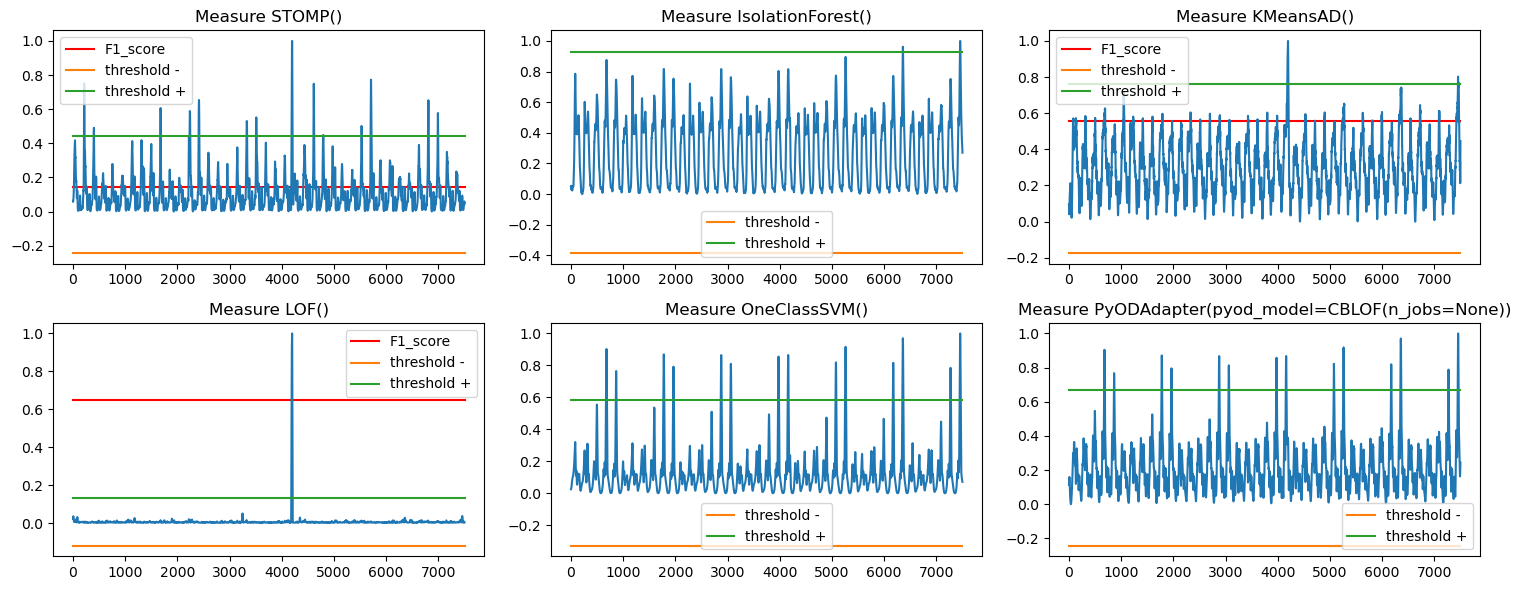

In [18]:
# TODO: In subplots plot the score of each method with their thresholds and the f1 score
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()  # to acess to the axes like lists

for i in range(6):
    if(F1_score[i] != -1):
        axes[i].plot([0,len(data)-1],[F1_score[i],F1_score[i]], label='F1_score',color='r')

    axes[i].plot(results["score"][i])
    axes[i].plot([0,len(data)-1],[results["threshold"][i][0],results["threshold"][i][0]],label='threshold -')
    axes[i].plot([0,len(data)-1],[results["threshold"][i][1],results["threshold"][i][1]],label='threshold +')
    axes[i].set_title(f"Measure {detectors[i]}")
    axes[i].legend()

plt.tight_layout()
plt.show()

> Remark : the reason no F1 score for these 3 is due to no TP (TP=0). One class SVM and PyOD seems to have a shift problem.

### Compute threshold-free metrics

In [19]:
# TODO: Compute precision and recall for multiple different thresholds
def precison_recall_thres(results,label,thres):
    TP=[0 for i in range(len(results["method"]))]
    FP=[0 for i in range(len(results["method"]))]
    FN=[0 for i in range(len(results["method"]))]
    TN=[0 for i in range(len(results["method"]))] #useless
    for i in range(len(results["method"])) : #each i represents a diff detector
        for j in range(len(label)) :
            if(abs(results["score"][i][j]) >= thres):
                if(label[j] >= 0.1):
                    TP[i]=TP[i]+1
                else :
                    FP[i]=FP[i]+1
            else :
                if(label[j] >= 0.1):
                    FN[i]=FN[i]+1
                else :
                    TN[i]=TN[i]+1
    precision=[0 for i in range(len(results["method"]))] #0 means error
    recall=[0 for i in range(len(results["method"]))]
    F1_score=[-1 for i in range(len(results["method"]))]
    for k in range(len(results["method"])):
        if(TP[k]+FP[k] != 0):
            precision[k]=TP[k]/(TP[k]+FP[k])
        if(TP[k]+FN[k] != 0):    
            recall[k]=TP[k]/(TP[k]+FN[k])
        if(precision[k] not in (0,-1) and recall[k] not in (0,-1)):
            F1_score[k] = 2*precision[k]*recall[k]/(precision[k]+recall[k])
    return precision, recall

print(precison_recall_thres(results,label,0.5)[0])
print(precison_recall_thres(results,label,0.5)[1])                

# for elem in results:
    # elem['precision'], elem['recall'], elem['threshold_list'] = ?

[0.10619469026548672, 0.0, 0.015727391874180863, 0.6666666666666666, 0.0, 0.0]
[1.0, 0.0, 1.0, 1.0, 0.0, 0.0]


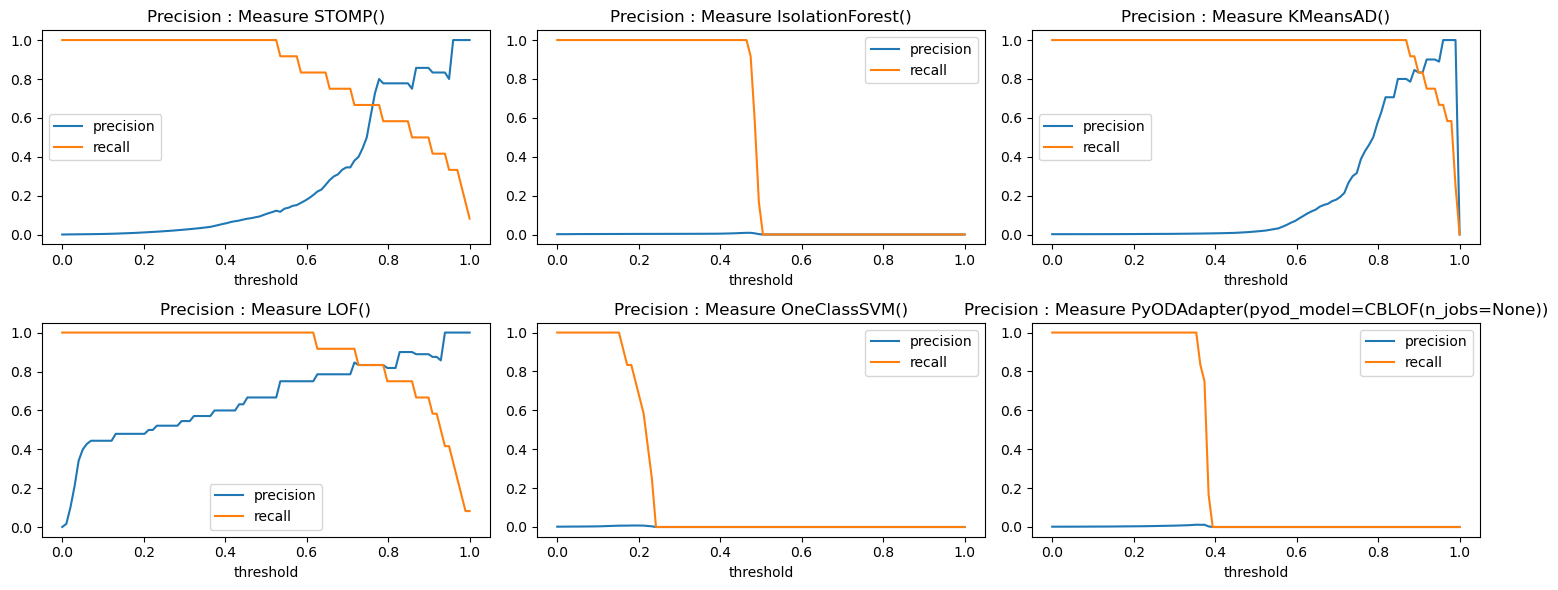

In [20]:
# TODO: Plot the precision recall curves for all methods and plot them in subplots

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()  # to acess to the axes like lists
x=np.linspace(0,1,100)
precision_by_x=[]
recall_by_x=[]
for i in range(len(x)): 
    p, r = precison_recall_thres(results, label, x[i]) 
    precision_by_x.append(p) 
    recall_by_x.append(r)
#pour réarranger
precision_by_x = [ [precision_by_x[i][j] for i in range(len(x))] for j in range(6) ]
recall_by_x = [ [recall_by_x[i][j] for i in range(len(x))] for j in range(6) ]

for i in range(6):
    axes[i].plot(x,precision_by_x[i],label='precision')
    axes[i].plot(x,recall_by_x[i],label='recall')
    axes[i].set_title(f"Precision : Measure {detectors[i]}")
    axes[i].set_xlabel("threshold")

    axes[i].legend()

plt.tight_layout()
plt.show()

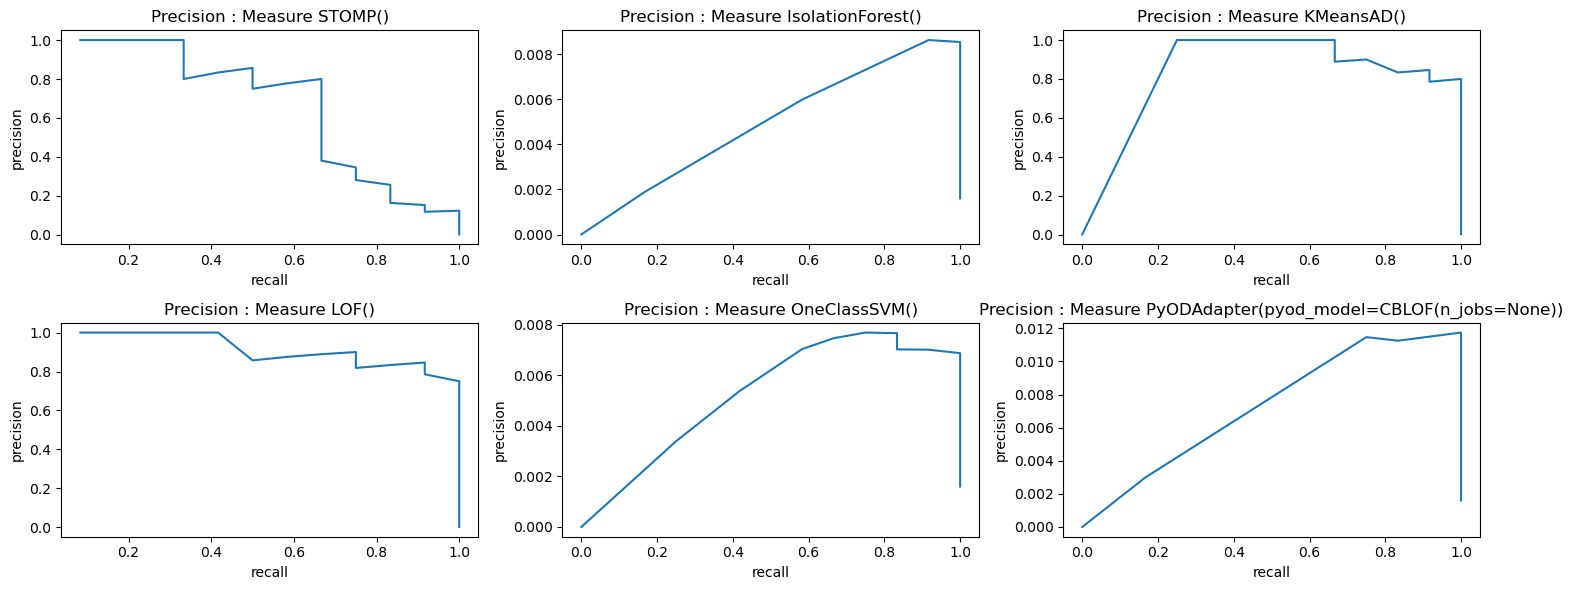

In [21]:
# TODO: Compute AUC-PR
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()  # to acess to the axes like lists

for i in range(6):
    axes[i].plot(recall_by_x[i],precision_by_x[i])
    axes[i].set_xlabel("recall")
    axes[i].set_ylabel("precision")

    axes[i].set_title(f"Precision : Measure {detectors[i]}")

plt.tight_layout()
plt.show()
# for i, elem in enumerate(results):
    # elem['AUC_PR'] = ?

### Compute timeseries-specific metrics

In [22]:
from aeon.benchmarking.metrics.anomaly_detection import (
    range_pr_auc_score,
    range_roc_auc_score)
# metrics = {
#     "RANGE_AUC_PR": range_pr_auc_score,
#     "RANGE_AUC_ROC": range_roc_auc_score,
# }

In [23]:
# TODO: Compute range-auc-pr, range-auc-roc
"""
def y_true(results,x):
        y_true=[[0 for i in range(len(results["score"]))] for i in range(len(results["method"]))]
        for i in range(len(results["method"])) : #each i represents a diff detector
            for j in range(len(results["score"])) :
                if(abs(results["score"][i][j]) >= x):
                    y_true[i][j]=1
"""
x=list(np.linspace(0,1,100))
pr_auc_detectors=[]
roc_auc_detectors=[]
for i in range(len(results["method"])):
    pr_auc_detectors.append(range_pr_auc_score(label, results["score"][i]))
    roc_auc_detectors.append(range_roc_auc_score(label, results["score"][i]))

>> The ROC is not a good performance tool because there is too few anomalies (FPR too low compared to TPR). Conversely the PR is very affected by the false negative then useful if the anomalies are seldoms.

In [24]:
# TODO: Create a dataframe with all your results
import pandas as pd

results["precision"] = precision
results["recall"] = recall
results["F1_score"] = F1_score
results["threshold_x"] = [x for i in range(len(results["method"]))]
results["precision_by_x"] = precision_by_x
results["recall_by_x"] = recall_by_x
results["pr_auc_detectors"] = pr_auc_detectors
results["roc_auc_detectors"] = roc_auc_detectors



rows = []

# Boucle sur chaque détecteur
for i, method in enumerate(results["method"]):

    # Boucle sur chaque seuil pour ce détecteur
    for j, thr in enumerate(results["threshold_x"][i]):

        rows.append({
            # Global metrics
            "method": method,
            "threshold": results["threshold_x"][i],
            "precision": results["precision"][i],
            "recall": results["recall"][i],
            "F1_score": results["F1_score"][i],
            "pr_auc_detectors": results["pr_auc_detectors"][i],
            "roc_auc_detectors": results["roc_auc_detectors"][i],
            # Specific metrics
            "threshold_by_x": results["threshold_x"][i][j],
            "precision_by_x": results["precision_by_x"][i][j],
            "recall_by_x": results["recall_by_x"][i][j]
        })
#It would be more pertinent to suppress altogether precision,threshold and recall

df = pd.DataFrame(rows)


print(df)

                                         method  ... recall_by_x
0                                       STOMP()  ...         1.0
1                                       STOMP()  ...         1.0
2                                       STOMP()  ...         1.0
3                                       STOMP()  ...         1.0
4                                       STOMP()  ...         1.0
..                                          ...  ...         ...
595  PyODAdapter(pyod_model=CBLOF(n_jobs=None))  ...         0.0
596  PyODAdapter(pyod_model=CBLOF(n_jobs=None))  ...         0.0
597  PyODAdapter(pyod_model=CBLOF(n_jobs=None))  ...         0.0
598  PyODAdapter(pyod_model=CBLOF(n_jobs=None))  ...         0.0
599  PyODAdapter(pyod_model=CBLOF(n_jobs=None))  ...         0.0

[600 rows x 10 columns]


### Summarize results

>>I will select the results being shown in a bar plot [We can only display a unique value per detectors] so some results must be condensed.
>>
>>The Optimal threshold (the only one we will select) is the one maximizing the product **recall*precision** depending on the situation (heart monitoring/ event prediction like shown in the course) we would prefer to weigh more recall or precision. With this optimal threshold we retrieve the precision,recall,F1_score and optimal threshold. We will also re-add the pr_auc_detectors and roc_auc_detectors (the runtime will be treated separatly).

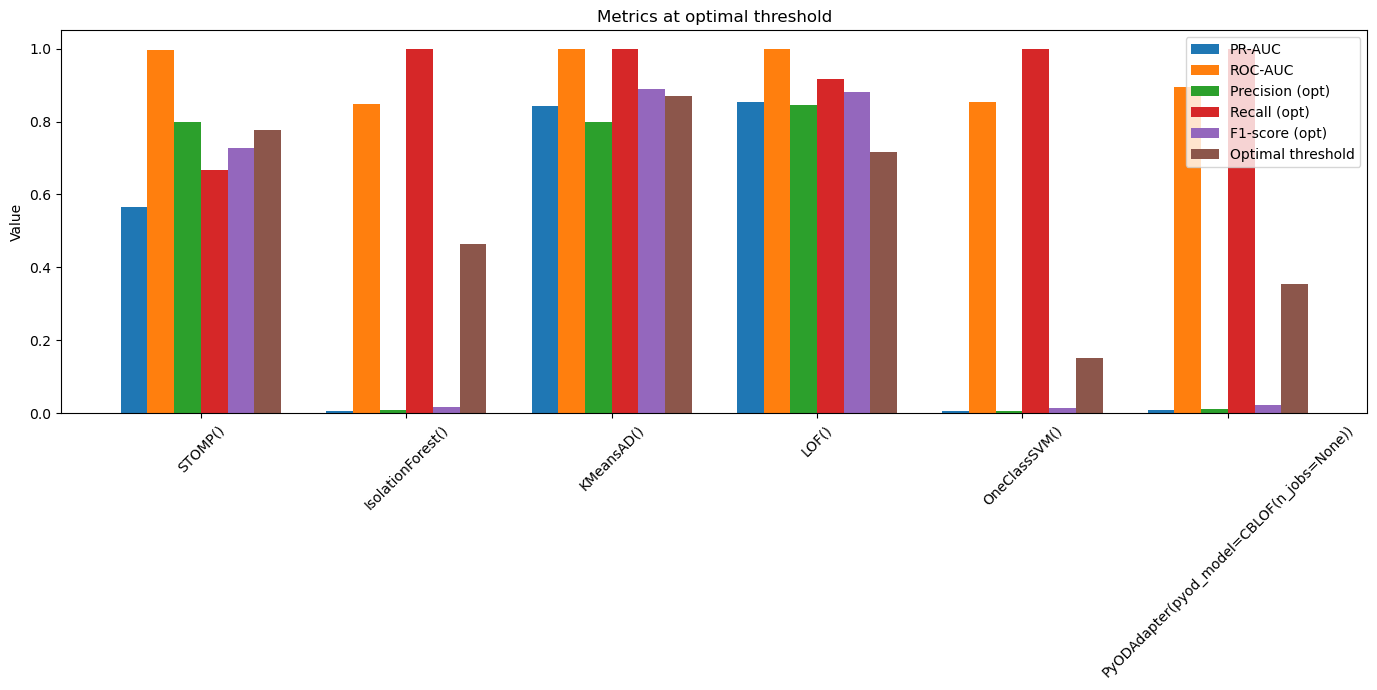

In [25]:
# TODO: Summarize all of the results with barplots

import matplotlib.pyplot as plt
import numpy as np

"""
# List of the keys
global_keys = [
    "precision",
    "recall",
    "F1_score"]
for k in (results.keys()) :
    if(k in global_keys):
        results[k]=[float(results[k][i]) for i in range(len(results[k]))]
"""


# Research of the optimal threshold
op_threshold = [0 for i in range(len(results["method"]))]
indx_th =[0 for i in range(len(results["method"]))]
j=0
for i in range(len(results["method"])):
    for j in range(len(results["threshold_x"][0])) :
        # the condition could change depending on our consideration of optimum
        if results["precision_by_x"][i][indx_th[i]]*results["recall_by_x"][i][indx_th[i]] <=results["precision_by_x"][i][j]*results["recall_by_x"][i][j]:
            op_threshold[i]=results["threshold_x"][0][j]
            indx_th[i]=j


F1_score_opt = []
results["precision"] = [0 for i in range(len(results["method"]))] 
results["recall"] = [0 for i in range(len(results["method"]))]

for i in range(len(results["method"])):#I reuse these keys
    results["precision"][i] = results["precision_by_x"][i][indx_th[i]]
    results["recall"][i] = results["recall_by_x"][i][indx_th[i]]

    if results["precision"][i] + results["recall"][i] > 0:
        F1_score_opt.append(2 * results["precision"][i] * results["recall"][i] / (results["precision"][i] + results["recall"][i]))
    else:
        F1_score_opt.append(-0.1)



x = np.arange(len(results["method"]))
width = 0.13

plt.figure(figsize=(14, 7))

plt.bar(x - 2.5*width, pr_auc_detectors, width, label="PR-AUC")
plt.bar(x - 1.5*width, roc_auc_detectors, width, label="ROC-AUC")
plt.bar(x - 0.5*width, results["precision"], width, label="Precision (opt)")
plt.bar(x + 0.5*width, results["recall"], width, label="Recall (opt)")
plt.bar(x + 1.5*width, F1_score_opt, width, label="F1-score (opt)")
plt.bar(x + 2.5*width, op_threshold, width, label="Optimal threshold")

plt.xticks(x, [str(results["method"][i]) for i in range(len(results["method"]))], rotation=45)
plt.ylabel("Value")
plt.title("Metrics at optimal threshold")
plt.legend()
plt.tight_layout()
plt.show()


        


>> Which is the best method in your opinion and why ?
>>
>> Because of the rarity of anomalies we would like to focus on the quality of detection of positive. F1_score and PR_AUC are 2 good metrics because they give : recall*precision which, as I said before is often tried to be maximized by a good treshold. F1_score has the added bonus of penalizing a disparity between FP and FN (examples explain why better).
>>
>> Ex : if it detects all the TP values and the threshold still lowers FN=0 BUT FP increase. If some TP values are lower than plenty of TN ones, the threshold will be biaised and lower to 'save' the most values (which is against the 'quality' of detection of positive).
>>
>> That's why LOF() is the best method (closely followed by KMeansAD() - the detector scoring graphs could have fooled us) because it's PR_AUC and F1_score wise the best method. Here it's the more pertinent because it detects jittering thanks to its density based model.

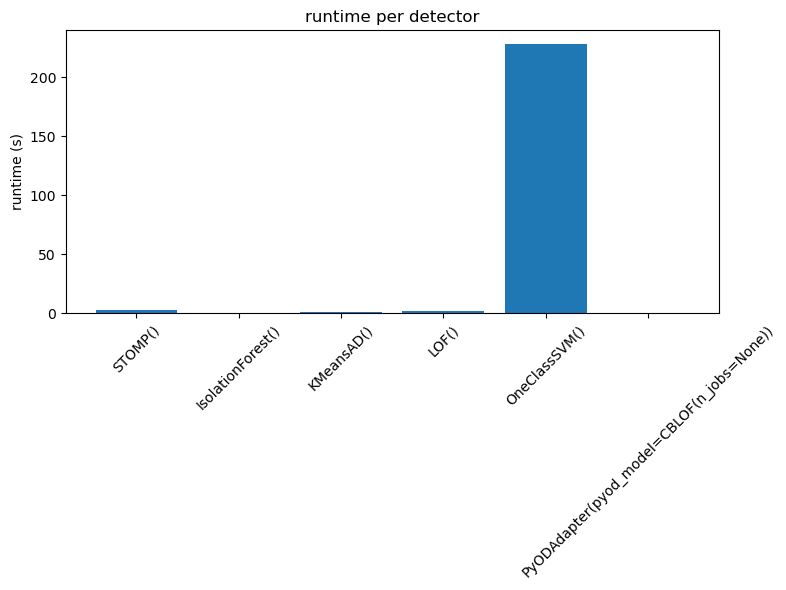

In [31]:
# TODO: Create bar plot to compare the runtime of the methods
#for i in range(len(results["method"])):
plt.figure(figsize=(8, 6))
plt.bar([str(results["method"][i]) for i in range(6)],results["runtime"])
plt.title(f"{results["method"][i]} (global)")
plt.ylabel("runtime (s)")
plt.xticks(rotation=45)
plt.title("runtime per detector")
plt.tight_layout()
plt.show()

>> The runtime is directly linked to the computation method, NOT the result : Isolation Forest is bad but the third fastest and KMeans works very well but is by a long shot the slowest. It confirms even more that LOF() is truly there the most well-adapted method.

## Bonus: Analyse datasets (20%)

- Load a few time series of different types from Aeon
- Run the detectors on each type
- What's the best detector? Is there a single best detector for all types of time series ?

In [26]:
# TODO: ?????

In [27]:
data, label = load_anomaly_detection(
name=("KDD-TSAD", "002_UCR_Anomaly_DISTORTED2sddb40")
)

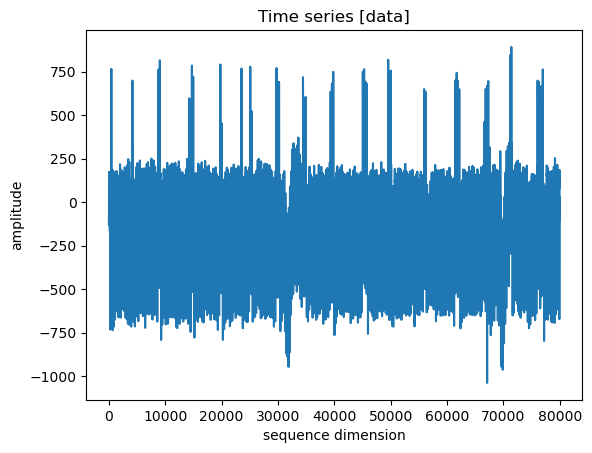

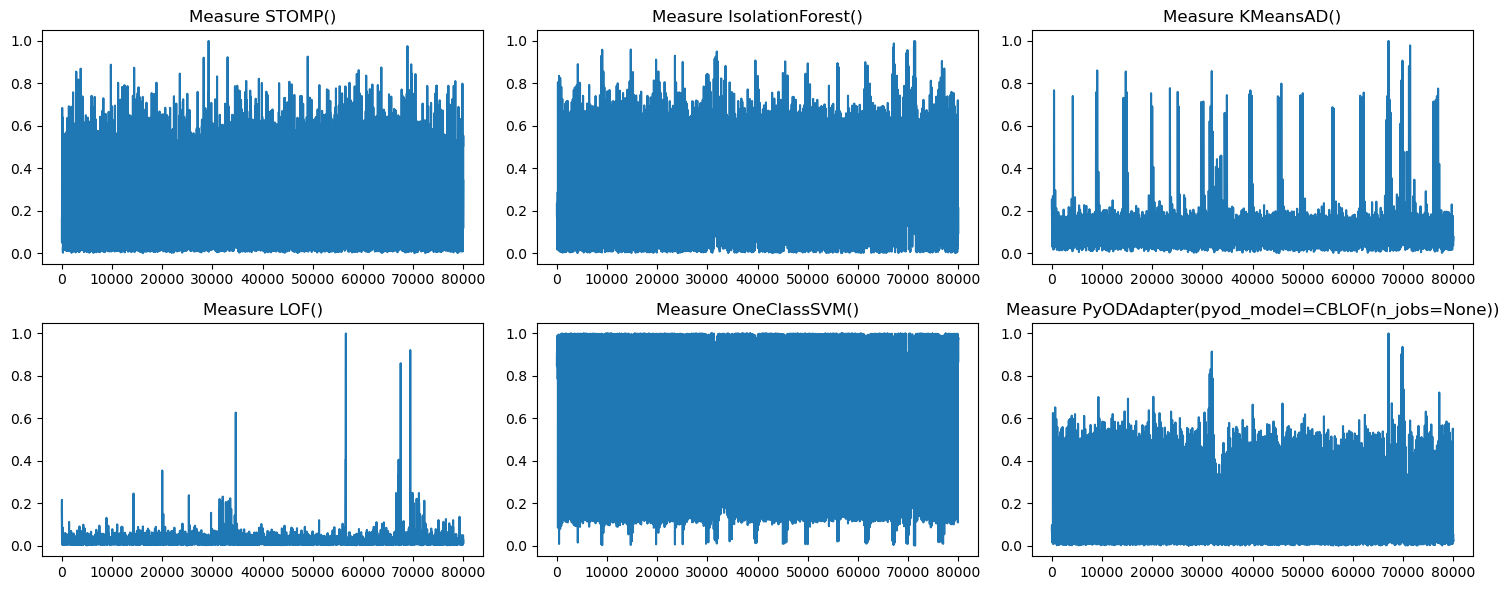

In [28]:
results = {"method": [], "score": [], "runtime" :[]} # Save your results here, use it as a list of dictionaries with keys {method, score, runtime}
detectors = [STOMP(), IsolationForest(), KMeansAD(), LOF(), OneClassSVM(), PyODAdapter(CBLOF())]

# TODO: Compute the anomaly scores from all detectors and measure run time
# TODO: Plot the original time series and the computed scores in subplots, use matplotlib
plt.plot(data)
plt.title("Time series [data]")
plt.xlabel("sequence dimension")
plt.ylabel("amplitude")
plt.show()

import time
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()  # to acess to the axes like lists


for i in range(6):
    time_meas=time.time()
    x=detectors[i].fit_predict(data)
    time_meas=time.time()-time_meas
    results["method"].append(detectors[i])
    results["score"].append(MinMaxScaler().fit_transform(np.array(x).reshape(-1,1)).ravel()) #to normalize the data
    results["runtime"].append(time_meas)
    axes[i].plot(MinMaxScaler().fit_transform(np.array(x).reshape(-1,1)).ravel())
    axes[i].set_title(f"Measure {detectors[i]}")

plt.tight_layout()
plt.show()


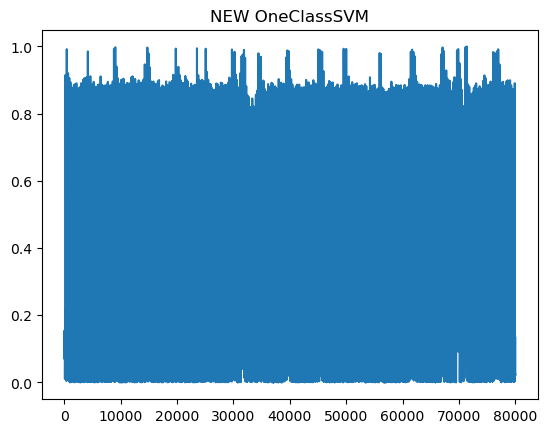

In [34]:
#reverse OneClassSVM
results["score"][4] = [abs(1-results["score"][4][i]) for i in range(len(results["score"][4]))]
plt.plot(results["score"][4])
plt.title("NEW OneClassSVM")
plt.show()

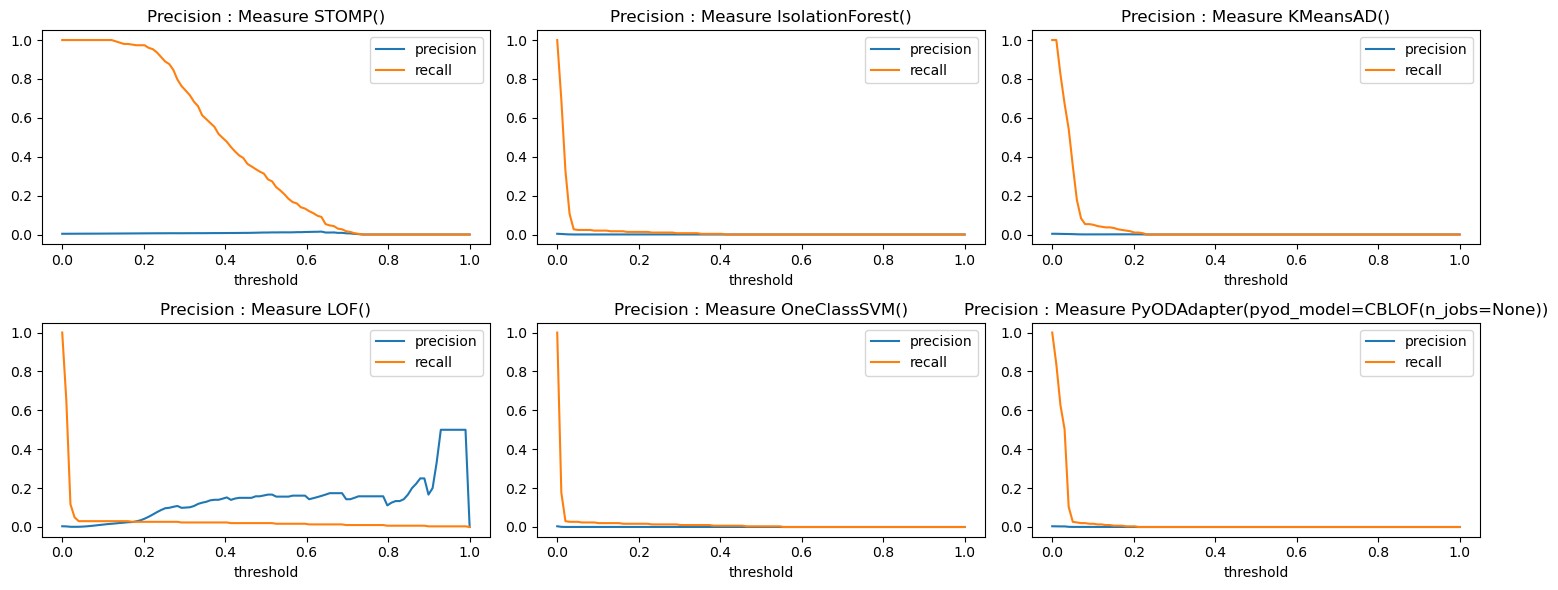

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()  # to acess to the axes like lists
x=np.linspace(0,1,100)
precision_by_x=[]
recall_by_x=[]
for i in range(len(x)): 
    p, r = precison_recall_thres(results, label, x[i]) 
    precision_by_x.append(p) 
    recall_by_x.append(r)
#pour réarranger
precision_by_x = [ [precision_by_x[i][j] for i in range(len(x))] for j in range(6) ]
recall_by_x = [ [recall_by_x[i][j] for i in range(len(x))] for j in range(6) ]

for i in range(6):
    axes[i].plot(x,precision_by_x[i],label='precision')
    axes[i].plot(x,recall_by_x[i],label='recall')
    axes[i].set_title(f"Precision : Measure {detectors[i]}")
    axes[i].set_xlabel("threshold")

    axes[i].legend()

plt.tight_layout()
plt.show()

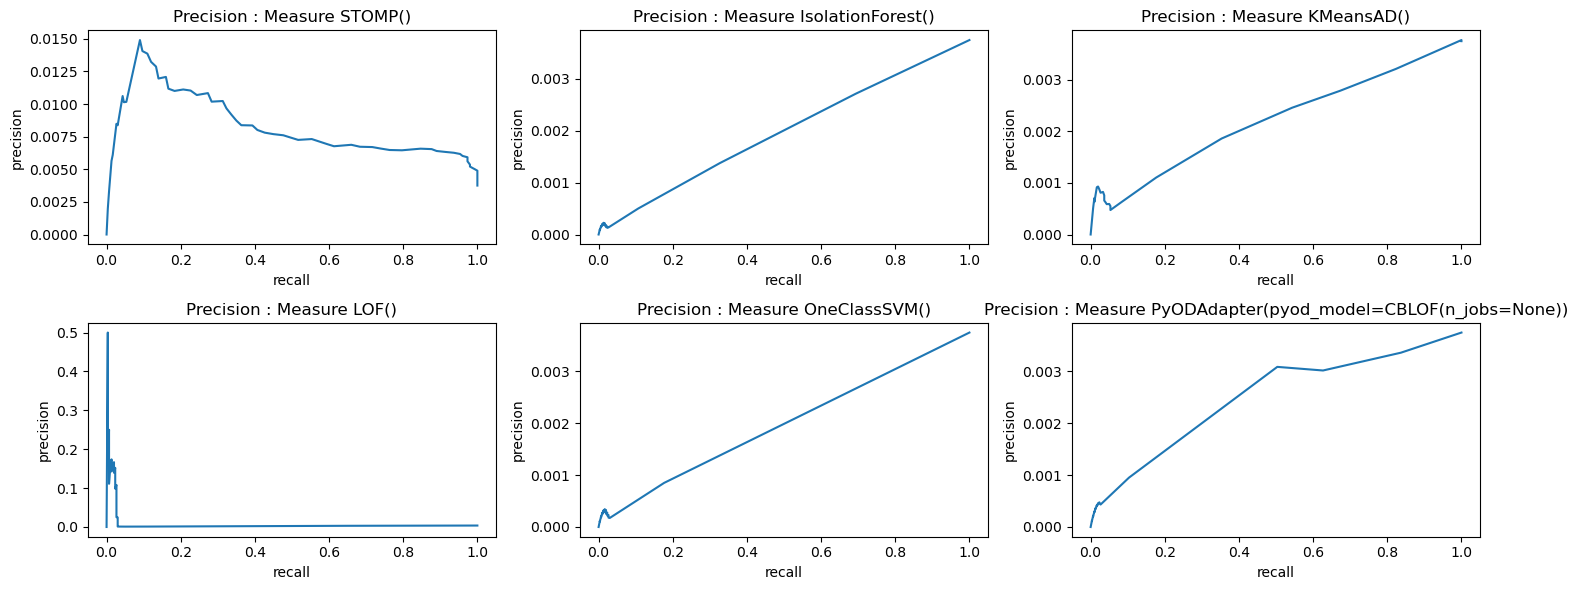

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()  # to acess to the axes like lists

for i in range(6):
    axes[i].plot(recall_by_x[i],precision_by_x[i])
    axes[i].set_xlabel("recall")
    axes[i].set_ylabel("precision")
    axes[i].set_title(f"Precision : Measure {detectors[i]}")

plt.tight_layout()
plt.show()

[np.float64(0.22222222222222224), np.float64(0.0), np.float64(0.010101010101010102), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


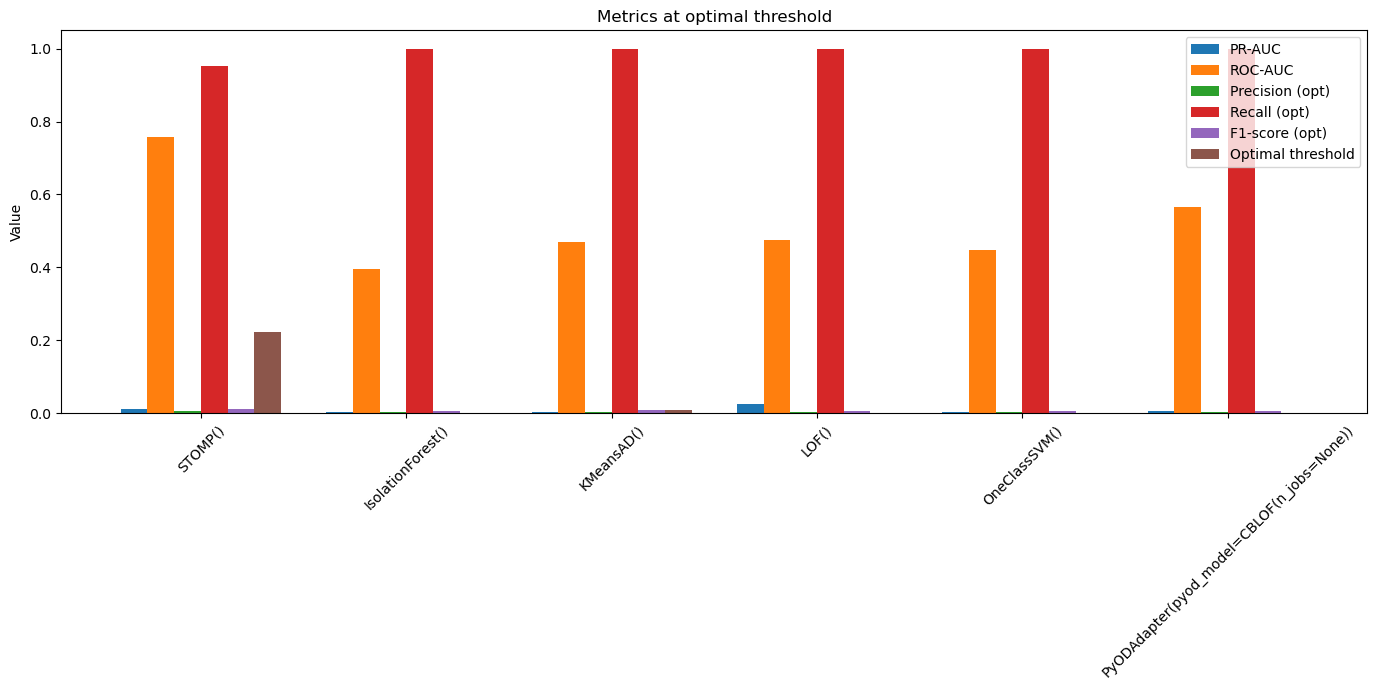

In [37]:
#PR-AUC / ROC-AUC
x=list(np.linspace(0,1,100))
pr_auc_detectors=[]
roc_auc_detectors=[]
for i in range(len(results["method"])):
    pr_auc_detectors.append(range_pr_auc_score(label, results["score"][i]))
    roc_auc_detectors.append(range_roc_auc_score(label, results["score"][i]))



# Research of the optimal threshold
op_threshold = [0 for i in range(len(results["method"]))]
indx_th =[0 for i in range(len(results["method"]))]
j=0
for i in range(len(results["method"])):
    for j in range(len(x)) :
        # the condition could change depending on our consideration of optimum
        if precision_by_x[i][indx_th[i]]*recall_by_x[i][indx_th[i]] <=precision_by_x[i][j]*recall_by_x[i][j]:
            op_threshold[i]=x[j]
            indx_th[i]=j

print(op_threshold)

F1_score_opt = []
results["precision"] = [0 for i in range(len(results["method"]))] 
results["recall"] = [0 for i in range(len(results["method"]))]

for i in range(len(results["method"])):#I reuse these keys
    results["precision"][i] = precision_by_x[i][indx_th[i]]
    results["recall"][i] = recall_by_x[i][indx_th[i]]

    if results["precision"][i] + results["recall"][i] > 0:
        F1_score_opt.append(2 * results["precision"][i] * results["recall"][i] / (results["precision"][i] + results["recall"][i]))
    else:
        F1_score_opt.append(-0.1)



x = np.arange(len(results["method"]))
width = 0.13

plt.figure(figsize=(14, 7))

plt.bar(x - 2.5*width, pr_auc_detectors, width, label="PR-AUC")
plt.bar(x - 1.5*width, roc_auc_detectors, width, label="ROC-AUC")
plt.bar(x - 0.5*width, results["precision"], width, label="Precision (opt)")
plt.bar(x + 0.5*width, results["recall"], width, label="Recall (opt)")
plt.bar(x + 1.5*width, F1_score_opt, width, label="F1-score (opt)")
plt.bar(x + 2.5*width, op_threshold, width, label="Optimal threshold")

plt.xticks(x, [str(results["method"][i]) for i in range(len(results["method"]))], rotation=45)
plt.ylabel("Value")
plt.title("Metrics at optimal threshold")
plt.legend()
plt.tight_layout()
plt.show()

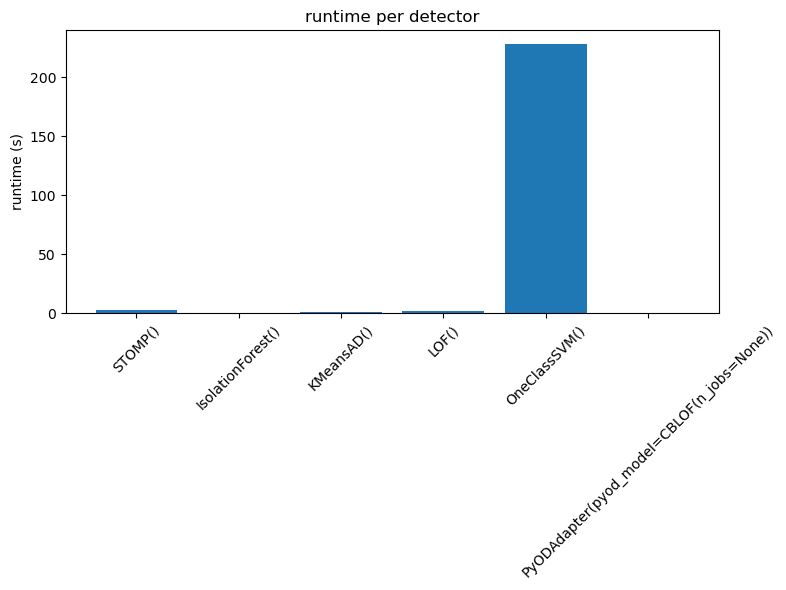

In [38]:
plt.figure(figsize=(8, 6))
plt.bar([str(results["method"][i]) for i in range(6)],results["runtime"])
plt.title(f"{results["method"][i]} (global)")
plt.ylabel("runtime (s)")
plt.xticks(rotation=45)
plt.title("runtime per detector")
plt.tight_layout()
plt.show()

>> Here we are in a extreme case where the anomalies are badly detected for all the methods. Here we still seek for the one with the highest PR-AUC.
>>
>> So LOF() is the best detector but it's still very bad compared to last data. The anomaly detection is very unprecise because of the amont of false positive so we need either to tweek our detectors or crating a metric focusing on the 'spikes' in scoring (we want to detect at least a pt in an area - we label score our data on the number of area discovered).

>> Also OneClassSVM() runtime is horendous in both cases.